In [9]:
import pandas as pd

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, BatchNormalization,SpatialDropout1D,Flatten,Bidirectional
from tensorflow.keras.models import Sequential

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score,roc_curve,classification_report
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
from sklearn.metrics import f1_score,accuracy_score

import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')




In [2]:
data =pd.read_csv('https://full-stack-bigdata-datasets.s3.eu-west-3.amazonaws.com/Deep+Learning/project/spam.csv',encoding='latin-1')

In [31]:
data

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [3]:
data=data.drop(['Unnamed: 2','Unnamed: 3','Unnamed: 4'],axis=1)
data=data.rename(columns={'v1':'spam','v2':'text'})
data=data.replace({'ham':0,'spam':1})

data

<ipython-input-3-f3d312696220>:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data=data.replace({'ham':0,'spam':1})


,spam,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


In [33]:
data.text.value_counts()

,count
text,
"Sorry, I'll call later",30
I cant pick the phone right now. Pls send a message,12
Ok...,10
"7 wonders in My WORLD 7th You 6th Ur style 5th Ur smile 4th Ur Personality 3rd Ur Nature 2nd Ur SMS and 1st \Ur Lovely Friendship\""... good morning dear""",4
"Say this slowly.? GOD,I LOVE YOU &amp; I NEED YOU,CLEAN MY HEART WITH YOUR BLOOD.Send this to Ten special people &amp; u c miracle tomorrow, do it,pls,pls do it...",4
...,...
I gotta collect da car at 6 lei.,1
No. On the way home. So if not for the long dry spell the season would have been over,1
Urgent! Please call 09061743811 from landline. Your ABTA complimentary 4* Tenerife Holiday or å£5000 cash await collection SAE T&Cs Box 326 CW25WX 150ppm,1


In [ ]:
data .text.isnull().sum()

0

In [ ]:
data.text.apply(lambda x:type(x)).value_counts()

,count
text,
<class 'str'>,5572


In [ ]:


px.pie(data.spam.value_counts(),names=['ham','spam'],values=data.spam.value_counts().values)

# `Preprocessing the dataset`

In [10]:
def preprocess_sequence(sentences, targets):
    """
    Tokenize, encode and pad sequences, and encode target labels.
    """
    # Tokenization
    tokenizer = Tokenizer(filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n', lower=True, split=' ')
    tokenizer.fit_on_texts(sentences)

    vocab_size = len(tokenizer.word_index) + 1
    print(f"Vocabulary Size: {vocab_size}")

    # Convert text to sequences and pad them
    X_padded = pad_sequences(tokenizer.texts_to_sequences(sentences), padding='post')

    # Label encoding
    encoder = LabelEncoder()
    y_encoded = encoder.fit_transform(targets)

    return X_padded, y_encoded, tokenizer, vocab_size

In [11]:

x_pad,y_enc,tokenizer,vocab_size=preprocess_sequence(data.text,data.spam)



Vocabulary Size: 8921


In [12]:

def prepare_dataset_tf(x_padded, y_encoded, test_size=0.2, batch_size=32, buffer_size=10000):
    """
    Split dataset into training and test sets and create TensorFlow datasets.
    """
    x_train, x_test, y_train, y_test = train_test_split(
        x_padded, y_encoded, test_size=test_size, stratify=y_encoded, random_state=42
    )

    train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train)).shuffle(buffer_size).batch(batch_size)
    test_dataset = tf.data.Dataset.from_tensor_slices((x_test, y_test)).shuffle(buffer_size).batch(batch_size)

    print(f"x_train shape: {x_train.shape}, x_test shape: {x_test.shape}")
    print(f"y_train shape: {y_train.shape}, y_test shape: {y_test.shape}")

    return train_dataset, test_dataset, x_train, x_test, y_train, y_test




In [13]:
train_tf,test_tf,x_train,x_test,y_train,y_test=prepare_dataset_tf(x_pad,y_enc,0.2,32,len(x_pad))

x_train shape: (4457, 189), x_test shape: (1115, 189)
y_train shape: (4457,), y_test shape: (1115,)


In [ ]:
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip glove.6B.zip
!rm glove.6B.200d.txt glove.6B.100d.txt rm glove.6B.50d.txt glove.6B.zip





--2025-02-06 19:30:47--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2025-02-06 19:30:47--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2025-02-06 19:30:47--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [20]:
!wget https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.fr.300.vec.gz
!gunzip cc.fr.300.vec.gz


--2025-02-07 15:04:23--  https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.fr.300.vec.gz
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 108.157.254.121, 108.157.254.15, 108.157.254.124, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|108.157.254.121|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1287757366 (1.2G) [binary/octet-stream]
Saving to: ‘cc.fr.300.vec.gz’

cc.fr.300.vec.gz    100%[===================>]   1.20G  23.4MB/s    in 63s     

2025-02-07 15:05:26 (19.6 MB/s) - ‘cc.fr.300.vec.gz’ saved [1287757366/1287757366]



In [14]:
def load_create_embedding_layer(embedding_file, vocab_size, embedding_dim, tokenizer, trainable=True):
    """
    Load pre-trained word embeddings or initialize a random embedding matrix.
    """
    if embedding_file:
        embeddings_index = {}
        with open(embedding_file, encoding="utf-8") as f:
            for line in f:
                values = line.split()
                word, coefs = values[0], np.asarray(values[1:], dtype=np.float32)
                embeddings_index[word] = coefs
        print(f"✅ {len(embeddings_index)} words loaded from {embedding_file}")

        embedding_matrix = np.random.uniform(-0.05, 0.05, (vocab_size, embedding_dim))
        for word, i in tokenizer.word_index.items():
            if i < vocab_size:
                embedding_vector = embeddings_index.get(word)
                if embedding_vector is not None:
                    embedding_matrix[i] = embedding_vector
        print(f"✅ Pre-trained embedding matrix created with shape {embedding_matrix.shape}")
    else:
        embedding_matrix = np.random.uniform(-0.05, 0.05, (vocab_size, embedding_dim))
        print(f"✅ Random embedding initialized with shape {embedding_matrix.shape}")

    return tf.keras.layers.Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix] if embedding_file else None,
        trainable=trainable
    )





In [ ]:
emb_glove=load_create_embedding_layer("glove.6B.300d.txt",vocab_size,300,tokenizer)

✅ 383176 words loaded from glove.6B.300d.txt
✅ Pre-trained embedding matrix created with shape (8921, 300)


In [ ]:
embedding_layer=load_create_embedding_layer(None,vocab_size,300,tokenizer)

✅ Embedding aléatoire créée avec shape (8921, 300)


In [15]:
def build_model(model_type, embedding_layer):
    model = tf.keras.Sequential([embedding_layer])

    if model_type == "fully_connected":
        model.add(tf.keras.layers.Flatten())
        model.add(tf.keras.layers.Dense(128, activation='relu'))
        model.add(tf.keras.layers.Dropout(0.3))
        model.add(tf.keras.layers.Dense(64, activation='relu'))
        model.add(tf.keras.layers.Dropout(0.3))
        model.add(tf.keras.layers.Dense(32, activation='relu'))
    elif model_type == "lstm":
        model.add(tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)))
        model.add(tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)))
        model.add(tf.keras.layers.Dense(16, activation='relu'))
        model.add(tf.keras.layers.Dropout(0.3))
    elif model_type == "cnn":
        model.add(tf.keras.layers.Conv1D(128, 5, activation='relu'))
        model.add(tf.keras.layers.GlobalMaxPooling1D())
        model.add(tf.keras.layers.Dense(64, activation='relu'))
        model.add(tf.keras.layers.Dropout(0.3))

    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [16]:
def decode_text_label(score):


    return "Spam" if score>0.5 else "Ham"

def decode_text_class(score):



    return 1 if score>0.5 else 0

In [17]:
def evaluate_keras_model(model, x_test, y_test):
    """
    Evaluate a trained Keras model and provide performance metrics.
    """
    pred_prob = model.predict(x_test)
    y_pred = [decode_text_class(score) for score in pred_prob]

    auc_score = roc_auc_score(y_test, pred_prob)
    f1 = f1_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)

    print(f"ROC AUC Score: {auc_score:.3f}")
    print(f"F1 Score: {f1:.3f}")
    print(f"Accuracy Score: {acc:.3f}")
    print(classification_report(y_test, y_pred))

    fpr, tpr, _ = roc_curve(y_test, pred_prob)
    plt.plot(fpr, tpr, label=f"AUC={auc_score:.3f}")
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.legend(loc=4)
    plt.show()

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["Ham", "Spam"]).plot()
    plt.show()

    return auc_score, f1, acc

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
ROC AUC score :  0.667
F1 Score :  0.248
Accuracy Score :  0.244


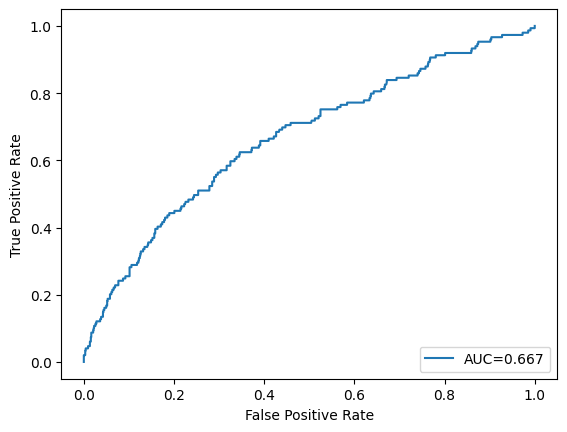

              precision    recall  f1-score   support

           0       0.93      0.14      0.24       966
           1       0.14      0.93      0.25       149

    accuracy                           0.24      1115
   macro avg       0.54      0.54      0.24      1115
weighted avg       0.82      0.24      0.24      1115



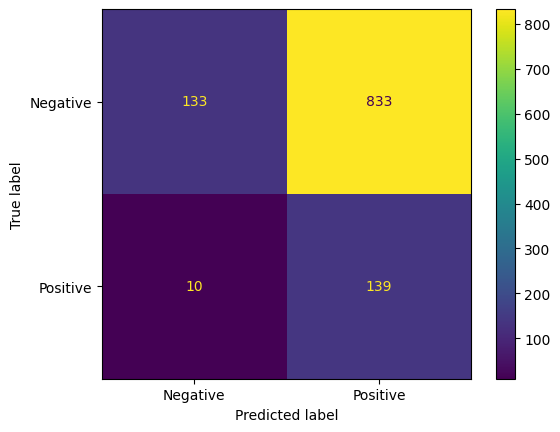

(0.6665242402767935, 0.248, 0.244)

In [ ]:
evaluate_keras_model(model,x_train,y_train,x_test,y_test)

In [18]:
def train_and_benchmark(models, embeddings, train_tf, test_tf, x_test, y_test, results_file="benchmark_results.csv"):
    os.makedirs("benchmark_results", exist_ok=True)
    results_path = os.path.join("benchmark_results", results_file)

    results = []
    for model_name, model_fn in models.items():  # model_name will be 'fully_connected', 'lstm', etc.
        for emb_name, emb_layer in embeddings.items():
            print(f"Training {model_name} with {emb_name} embeddings...")
            # Pass the model_name as the first argument to build_model
            model = model_fn(model_name, emb_layer)
            model.fit(train_tf, epochs=10, validation_data=test_tf, verbose=1)
            auc, f1, acc = evaluate_keras_model(model, x_test, y_test)

            results.append({"Model": model_name, "Embedding": emb_name, "AUC": auc, "F1": f1, "Accuracy": acc})
            model.save(os.path.join("benchmark_results", f"{model_name}_{emb_name}.h5"))

    df_results = pd.DataFrame(results)
    df_results.to_csv(results_path, index=False)
    print(f"✅ Benchmark results saved to {results_path}")






Lancer l'entrainement

In [21]:
x_enc, y_enc, tokenizer, vocab_size = preprocess_sequence(data.text, data.spam)


MODEL_DICT = {
    "fully_connected": build_model,
    "lstm": build_model,
    "cnn": build_model,
}

EMB_DICT = {
    "glove": load_create_embedding_layer("glove.6B.300d.txt", vocab_size, 300, tokenizer),
    "fasttext": load_create_embedding_layer("cc.fr.300.vec", vocab_size, 300, tokenizer),
    "random": load_create_embedding_layer(None, vocab_size, 300, tokenizer)
}







Vocabulary Size: 8921
✅ 32771 words loaded from glove.6B.300d.txt
✅ Pre-trained embedding matrix created with shape (8921, 300)
✅ 2000000 words loaded from cc.fr.300.vec
✅ Pre-trained embedding matrix created with shape (8921, 300)
✅ Random embedding initialized with shape (8921, 300)


x_train shape: (4457, 189), x_test shape: (1115, 189)
y_train shape: (4457,), y_test shape: (1115,)
Training fully_connected with glove embeddings...
Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 37s 235ms/step - accuracy: 0.8834 - loss: 0.2927 - val_accuracy: 0.9776 - val_loss: 0.0676
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 37s 206ms/step - accuracy: 0.9825 - loss: 0.0571 - val_accuracy: 0.9830 - val_loss: 0.0582
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 43s 225ms/step - accuracy: 0.9968 - loss: 0.0151 - val_accuracy: 0.9812 - val_loss: 0.0743
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 32s 159ms/step - accuracy: 0.9985 - loss: 0.0049 - val_accuracy: 0.9812 - val_loss: 0.1097
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 30s 218ms/step - accuracy: 0.9985 - loss: 0.0089 - val_accuracy: 0.9794 - val_loss: 0.1555
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 22s 158ms/step - accuracy: 0.9905 - loss: 0.0247 - val_accuracy: 0.9830 - val_loss: 0.0958
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 46s 191ms/step - accurac

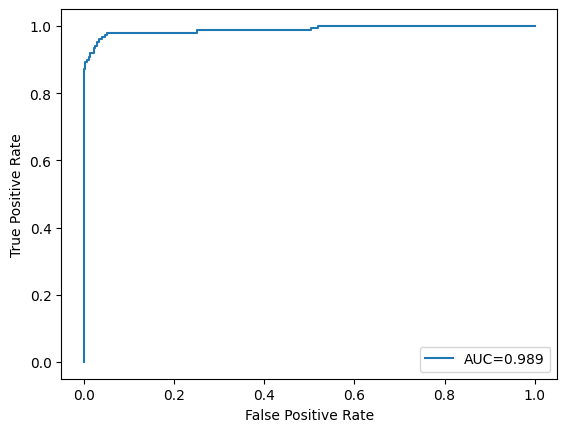

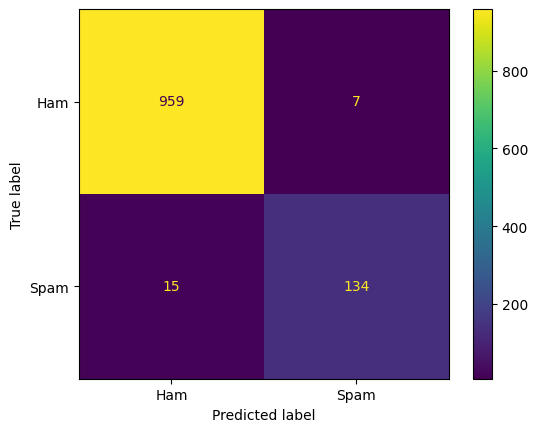

Training fully_connected with fasttext embeddings...
Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 43s 267ms/step - accuracy: 0.8325 - loss: 0.4305 - val_accuracy: 0.9722 - val_loss: 0.1127
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 29s 179ms/step - accuracy: 0.9849 - loss: 0.0547 - val_accuracy: 0.9812 - val_loss: 0.0784
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 31s 221ms/step - accuracy: 0.9954 - loss: 0.0164 - val_accuracy: 0.9874 - val_loss: 0.0847
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 29s 210ms/step - accuracy: 0.9992 - loss: 0.0028 - val_accuracy: 0.9865 - val_loss: 0.0748
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 26s 185ms/step - accuracy: 0.9995 - loss: 0.0015 - val_accuracy: 0.9874 - val_loss: 0.0611
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 40s 178ms/step - accuracy: 0.9995 - loss: 0.0018 - val_accuracy: 0.9803 - val_loss: 0.1167
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 42s 187ms/step - accuracy: 0.9962 - loss: 0.0173 - val_accuracy: 0.9865 - val_loss: 0.0887
Epoch 8/10
140/140 ━━━━━━━━━━━

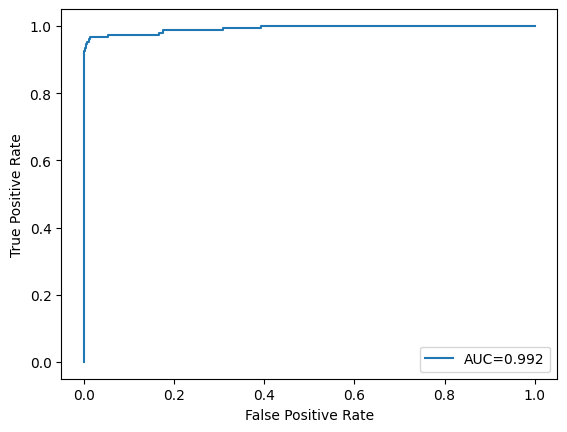

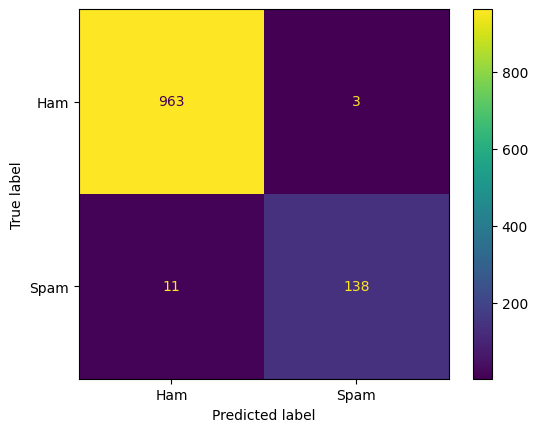

Training fully_connected with random embeddings...
Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 33s 201ms/step - accuracy: 0.8624 - loss: 0.3402 - val_accuracy: 0.9839 - val_loss: 0.0547
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 40s 195ms/step - accuracy: 0.9857 - loss: 0.0596 - val_accuracy: 0.9839 - val_loss: 0.0539
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 39s 181ms/step - accuracy: 0.9943 - loss: 0.0203 - val_accuracy: 0.9435 - val_loss: 0.1329
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 42s 185ms/step - accuracy: 0.9757 - loss: 0.0778 - val_accuracy: 0.9865 - val_loss: 0.0906
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 29s 210ms/step - accuracy: 0.9985 - loss: 0.0049 - val_accuracy: 0.9865 - val_loss: 0.0856
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 39s 197ms/step - accuracy: 0.9980 - loss: 0.0050 - val_accuracy: 0.9865 - val_loss: 0.0968
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 28s 200ms/step - accuracy: 0.9999 - loss: 3.3476e-04 - val_accuracy: 0.9865 - val_loss: 0.1385
Epoch 8/10
140/140 ━━━━━━━━━

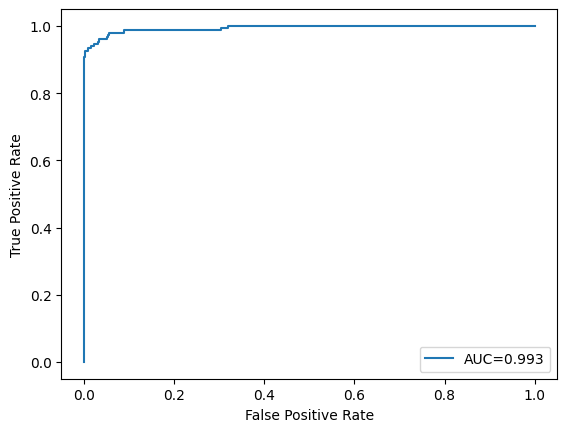

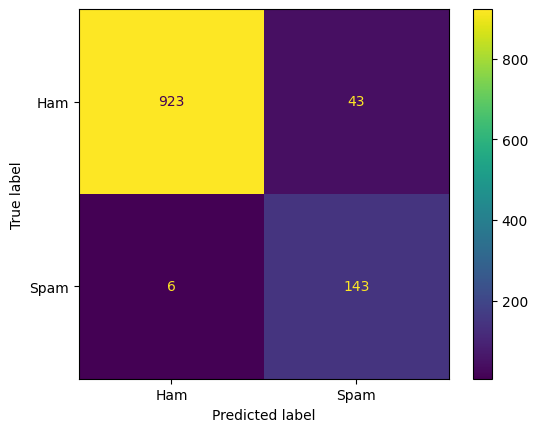

Training lstm with glove embeddings...
Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 192s 1s/step - accuracy: 0.9276 - loss: 0.2145 - val_accuracy: 0.9892 - val_loss: 0.0490
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 198s 1s/step - accuracy: 0.9965 - loss: 0.0205 - val_accuracy: 0.9892 - val_loss: 0.0418
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 199s 1s/step - accuracy: 0.9976 - loss: 0.0107 - val_accuracy: 0.9883 - val_loss: 0.0580
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 195s 1s/step - accuracy: 0.9982 - loss: 0.0073 - val_accuracy: 0.9857 - val_loss: 0.0479
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 176s 1s/step - accuracy: 0.9998 - loss: 0.0035 - val_accuracy: 0.9874 - val_loss: 0.1020
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 173s 1s/step - accuracy: 0.9994 - loss: 0.0038 - val_accuracy: 0.9883 - val_loss: 0.0687
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 184s 1s/step - accuracy: 0.9997 - loss: 0.0026 - val_accuracy: 0.9892 - val_loss: 0.0857
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 224s 1s/step - acc

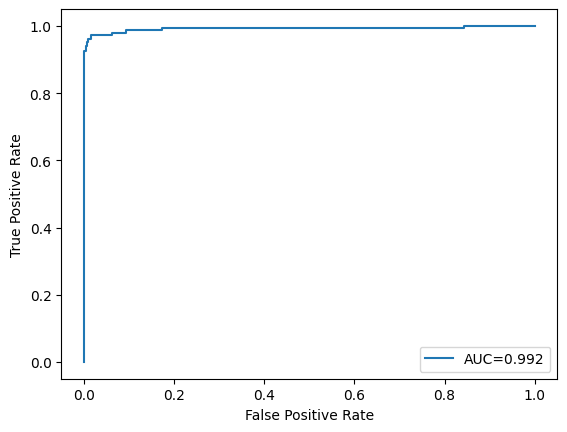

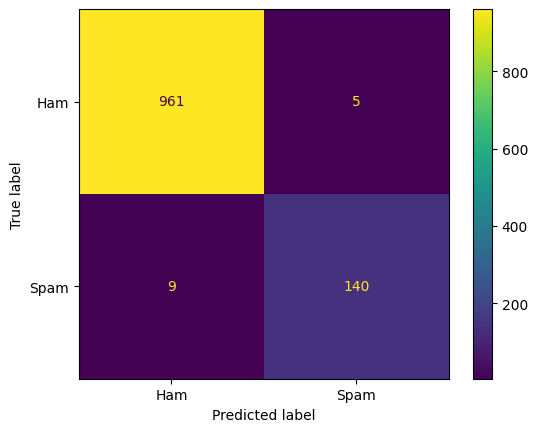

Training lstm with fasttext embeddings...
Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 183s 1s/step - accuracy: 0.9333 - loss: 0.1981 - val_accuracy: 0.9874 - val_loss: 0.0560
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 208s 1s/step - accuracy: 0.9947 - loss: 0.0190 - val_accuracy: 0.9874 - val_loss: 0.0645
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 206s 1s/step - accuracy: 0.9994 - loss: 0.0080 - val_accuracy: 0.9901 - val_loss: 0.0686
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 165s 1s/step - accuracy: 0.9998 - loss: 0.0036 - val_accuracy: 0.9865 - val_loss: 0.0905
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 177s 1s/step - accuracy: 0.9991 - loss: 0.0059 - val_accuracy: 0.9865 - val_loss: 0.0938
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 171s 1s/step - accuracy: 0.9983 - loss: 0.0037 - val_accuracy: 0.9883 - val_loss: 0.0907
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 167s 1s/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.9874 - val_loss: 0.1095
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 200s 1s/step - 

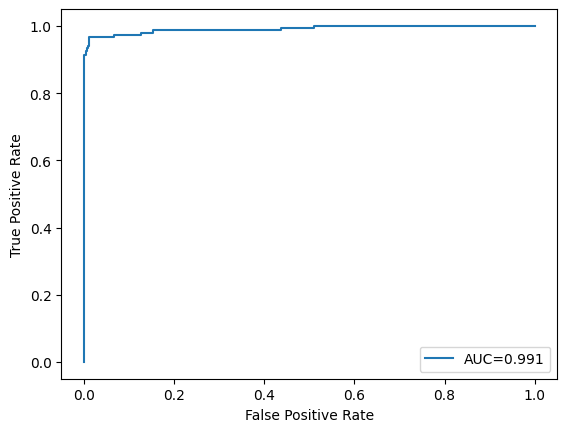

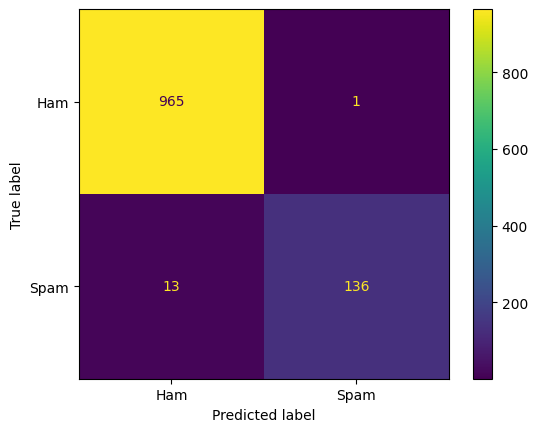

Training lstm with random embeddings...
Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 186s 1s/step - accuracy: 0.9244 - loss: 0.1962 - val_accuracy: 0.9830 - val_loss: 0.0807
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 176s 1s/step - accuracy: 0.9982 - loss: 0.0282 - val_accuracy: 0.9821 - val_loss: 0.1355
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 205s 1s/step - accuracy: 1.0000 - loss: 0.0087 - val_accuracy: 0.9883 - val_loss: 0.1059
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 183s 1s/step - accuracy: 1.0000 - loss: 0.0074 - val_accuracy: 0.9865 - val_loss: 0.1083
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 168s 1s/step - accuracy: 0.9994 - loss: 0.0094 - val_accuracy: 0.9821 - val_loss: 0.1797
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 174s 1s/step - accuracy: 0.9988 - loss: 0.0120 - val_accuracy: 0.9848 - val_loss: 0.1192
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 180s 1s/step - accuracy: 0.9993 - loss: 0.0099 - val_accuracy: 0.9857 - val_loss: 0.1329
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 186s 1s/step - ac

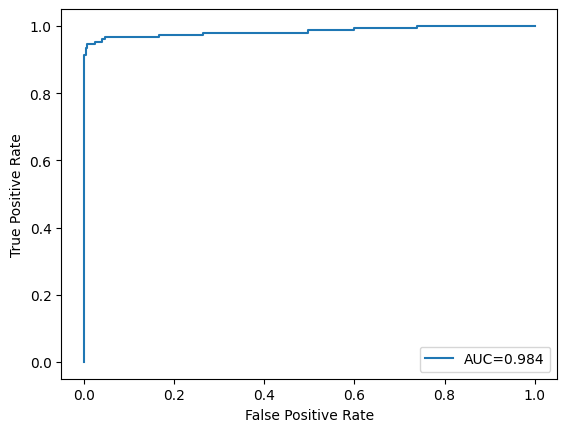

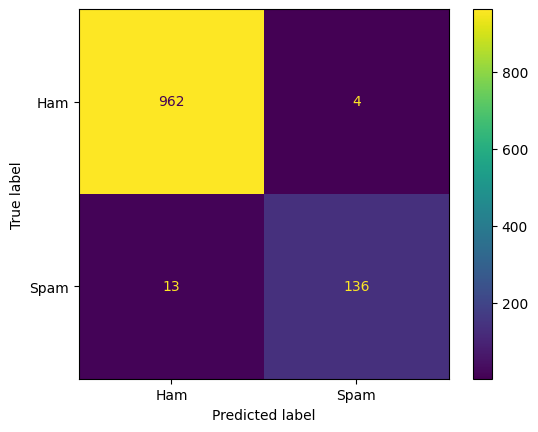

Training cnn with glove embeddings...
Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 44s 292ms/step - accuracy: 0.9320 - loss: 0.1398 - val_accuracy: 0.9928 - val_loss: 0.0395
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 83s 298ms/step - accuracy: 0.9987 - loss: 0.0044 - val_accuracy: 0.9919 - val_loss: 0.0416
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 86s 328ms/step - accuracy: 1.0000 - loss: 5.0294e-04 - val_accuracy: 0.9928 - val_loss: 0.0422
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 45s 322ms/step - accuracy: 1.0000 - loss: 3.5357e-04 - val_accuracy: 0.9901 - val_loss: 0.0504
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 78s 291ms/step - accuracy: 1.0000 - loss: 1.8944e-04 - val_accuracy: 0.9910 - val_loss: 0.0502
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 41s 297ms/step - accuracy: 1.0000 - loss: 1.1033e-04 - val_accuracy: 0.9919 - val_loss: 0.0508
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 42s 299ms/step - accuracy: 1.0000 - loss: 8.0708e-05 - val_accuracy: 0.9919 - val_loss: 0.0527
Epoch 8/10
140/140 ━━━━━━

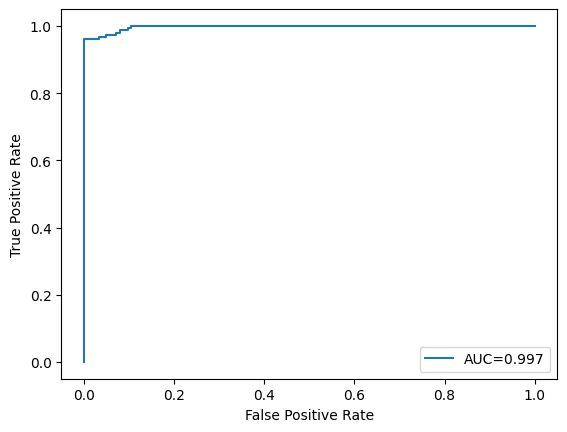

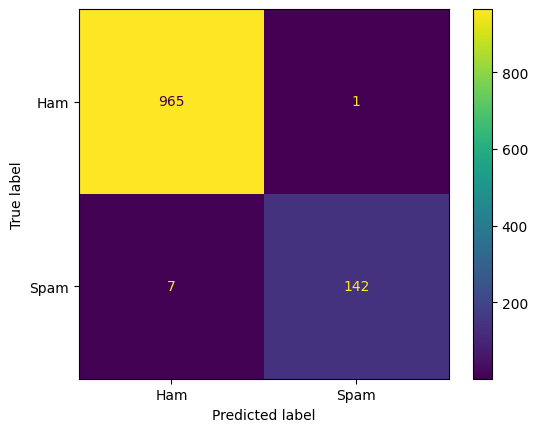

Training cnn with fasttext embeddings...
Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 44s 303ms/step - accuracy: 0.9337 - loss: 0.1344 - val_accuracy: 0.9839 - val_loss: 0.0528
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 41s 296ms/step - accuracy: 0.9980 - loss: 0.0040 - val_accuracy: 0.9919 - val_loss: 0.0579
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 80s 283ms/step - accuracy: 1.0000 - loss: 5.3739e-04 - val_accuracy: 0.9892 - val_loss: 0.0573
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 43s 297ms/step - accuracy: 1.0000 - loss: 4.7552e-04 - val_accuracy: 0.9883 - val_loss: 0.0649
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 82s 296ms/step - accuracy: 1.0000 - loss: 1.2909e-04 - val_accuracy: 0.9892 - val_loss: 0.0661
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 81s 290ms/step - accuracy: 1.0000 - loss: 6.6267e-05 - val_accuracy: 0.9901 - val_loss: 0.0678
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 45s 318ms/step - accuracy: 1.0000 - loss: 6.1036e-05 - val_accuracy: 0.9883 - val_loss: 0.0706
Epoch 8/10
140/140 ━━━

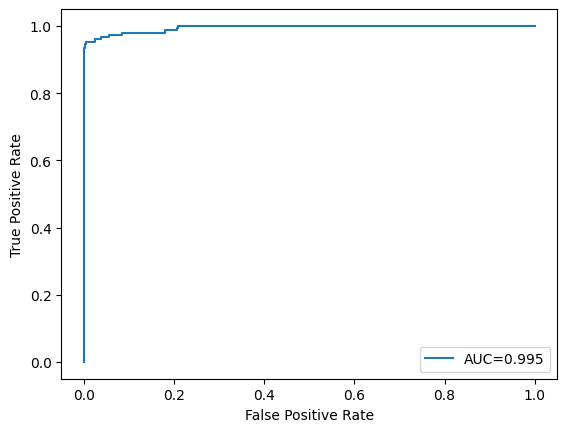

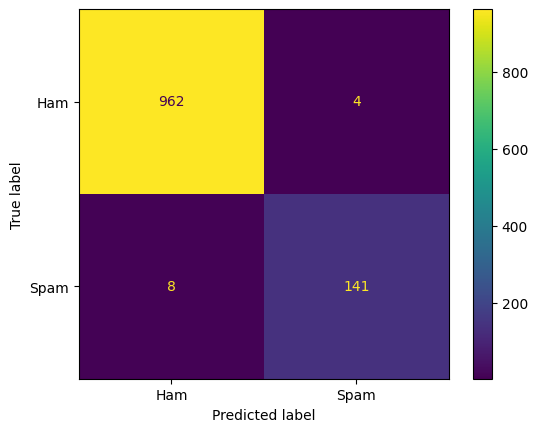

Training cnn with random embeddings...
Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 57s 378ms/step - accuracy: 0.9518 - loss: 0.1139 - val_accuracy: 0.9865 - val_loss: 0.0592
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 71s 301ms/step - accuracy: 0.9998 - loss: 8.4569e-04 - val_accuracy: 0.9883 - val_loss: 0.0705
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 42s 300ms/step - accuracy: 1.0000 - loss: 2.3920e-04 - val_accuracy: 0.9883 - val_loss: 0.0725
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 52s 375ms/step - accuracy: 1.0000 - loss: 1.1468e-04 - val_accuracy: 0.9892 - val_loss: 0.0801
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 80s 360ms/step - accuracy: 1.0000 - loss: 1.8456e-04 - val_accuracy: 0.9874 - val_loss: 0.0847
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 75s 314ms/step - accuracy: 1.0000 - loss: 5.6817e-05 - val_accuracy: 0.9874 - val_loss: 0.0840
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 80s 303ms/step - accuracy: 1.0000 - loss: 4.4003e-05 - val_accuracy: 0.9857 - val_loss: 0.0889
Epoch 8/10
140/140 ━

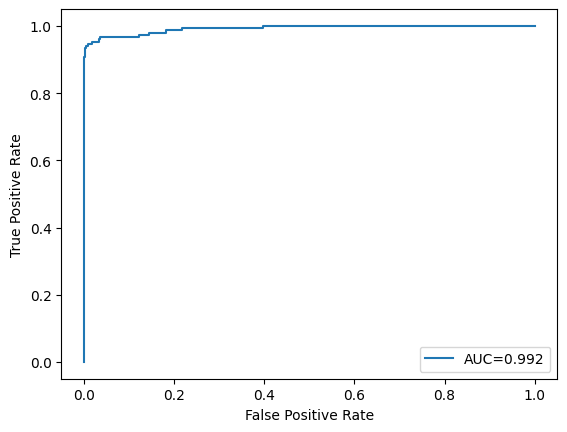

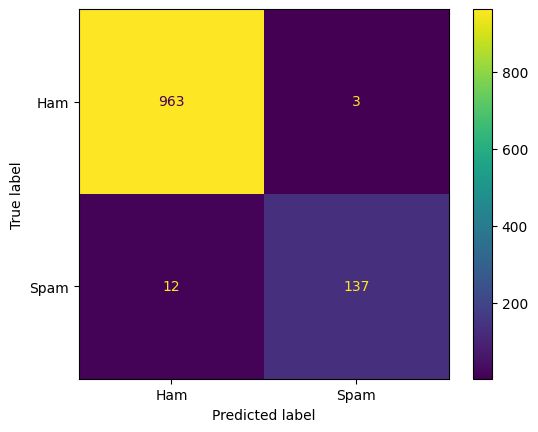

✅ Benchmark results saved to benchmark_results/benchmark_results.csv


In [35]:
train_tf, test_tf, x_train, x_test, y_train, y_test = prepare_dataset_tf(x_enc, y_enc, 0.2, 32, len(x_enc))

train_and_benchmark(MODEL_DICT, EMB_DICT, train_tf, test_tf, x_test, y_test)

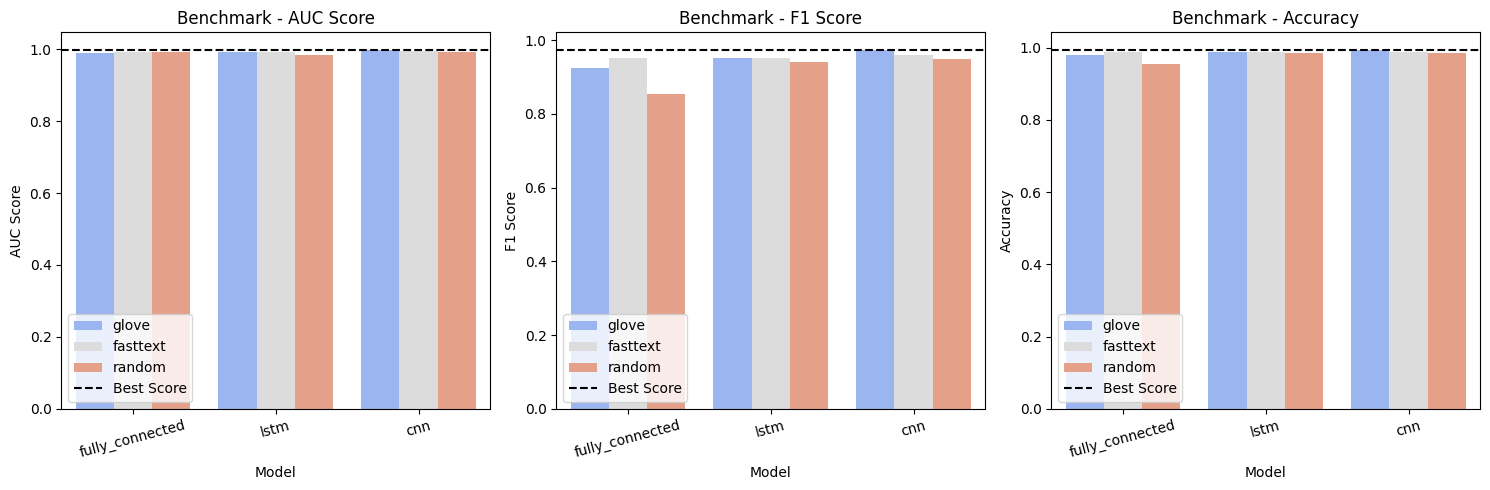

In [36]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def benchmark_results(csv_file="benchmark_results/benchmark_results.csv"):
    """
    Charge le fichier CSV des résultats et génère un benchmark des performances.

    Params:
    - csv_file (str) : Chemin du fichier CSV contenant les résultats.

    Retourne:
    - Affichage de 3 graphiques comparant AUC, F1 Score, et Accuracy.
    """
    # Vérifier si le fichier existe
    if not os.path.exists(csv_file):
        print(f"❌ Le fichier {csv_file} n'existe pas.")
        return

    # Charger les résultats
    df = pd.read_csv(csv_file)

    # Renommer les colonnes si nécessaire
    df.rename(columns={"AUC": "AUC Score", "F1": "F1 Score"}, inplace=True)

    # Configuration des graphiques
    metrics = ["AUC Score", "F1 Score", "Accuracy"]
    titles = ["Benchmark - AUC Score", "Benchmark - F1 Score", "Benchmark - Accuracy"]

    plt.figure(figsize=(15, 5))

    for i, metric in enumerate(metrics):
        plt.subplot(1, 3, i+1)
        sns.barplot(x="Model", y=metric, hue="Embedding", data=df, palette="coolwarm")

        # Ajout d'un trait pour le meilleur score
        best_score = df[metric].max()
        plt.axhline(y=best_score, color="black", linestyle="dashed", linewidth=1.5, label="Best Score")

        plt.title(titles[i])
        plt.xticks(rotation=15)
        plt.legend()

    plt.tight_layout()
    plt.show()

# Exécuter le benchmark
benchmark_results()


TRANSFER LERANING avec BERT

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

def benchmark_results(csv_file="benchmark_results/benchmark_results.csv"):
    """
    Charge le fichier CSV des résultats et génère un benchmark des performances.

    Params:
    - csv_file (str) : Chemin du fichier CSV contenant les résultats.

    Retourne:
    - Affichage de 3 graphiques comparant AUC, F1 Score, et Accuracy.
    """
    # Vérifier si le fichier existe
    if not os.path.exists(csv_file):
        print(f"❌ Le fichier {csv_file} n'existe pas.")
        return

    # Charger les résultats
    df = pd.read_csv(csv_file)

    # Renommer les colonnes si nécessaire
    df.rename(columns={"AUC": "AUC Score", "F1": "F1 Score"}, inplace=True)

    # Configuration des graphiques
    metrics = ["AUC Score", "F1 Score", "Accuracy"]
    titles = ["Benchmark - AUC Score", "Benchmark - F1 Score", "Benchmark - Accuracy"]

    plt.figure(figsize=(15, 5))

    for i, metric in enumerate(metrics):
        plt.subplot(1, 3, i+1)
        sns.barplot(x="Model", y=metric, hue="Embedding", data=df, palette="coolwarm")

        # Ajout d'un trait pour le meilleur score
        best_score = df[metric].max()
        plt.axhline(y=best_score, color="black", linestyle="dashed", linewidth=1.5, label="Best Score")

        plt.title(titles[i])
        plt.xticks(rotation=15)
        plt.legend()

    plt.tight_layout()
    plt.show()

class SpamDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=512):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors="pt"
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

def train_bert_spam_classifier(data_path):
    df = pd.read_csv(data_path)
    df['label'] = df['label'].map({'ham': 0, 'spam': 1})
    train_texts, test_texts, train_labels, test_labels = train_test_split(df['text'].tolist(), df['label'].tolist(), test_size=0.2)

    tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
    train_dataset = SpamDataset(train_texts, train_labels, tokenizer)
    test_dataset = SpamDataset(test_texts, test_labels, tokenizer)

    model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)
    training_args = TrainingArguments(
        output_dir="./results",
        evaluation_strategy="epoch",
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=3,
        weight_decay=0.01,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset
    )

    trainer.train()
    trainer.evaluate()
    model.save_pretrained("bert_spam_classifier")
    tokenizer.save_pretrained("bert_spam_classifier")

# Exécuter le benchmark
benchmark_results()


❌ Le fichier benchmark_results/benchmark_results.csv n'existe pas.
